Se debe utilizar el dataset CuMiDa.

Debe considerar al menos:

PCA: 
- [x] Justificar la selección de varianza explicada 
- [x] Interpretar los loadings de los primeros componentes
- [x] Visualizar los primeros componentes coloreando por clase

LR: 
- [ ] Explorar algoritmos revisados en clases (Grid search). 
- [ ] Obtener e interpretar métricas de clasificación vistas en clases.

Subir a un repositorio público y adjuntar el link.



In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
data = pd.read_csv('./data/Breast_GSE45827.csv')
data

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,230,luminal_B,10.392638,7.334408,6.848586,7.020486,3.228065,7.815439,5.448470,4.496955,...,12.638556,12.122129,14.331152,14.133976,8.495888,4.971727,6.209136,2.852852,3.697448,3.333289
147,233,luminal_B,10.930875,8.415294,5.906827,7.753572,3.270557,7.367931,5.906849,5.194349,...,12.523507,11.977970,14.285405,14.070989,8.193182,6.528948,7.108210,2.929800,3.833289,3.213893
148,236,luminal_B,11.027098,7.180876,6.304736,7.641197,3.206950,8.569296,5.823146,4.617309,...,12.256767,11.661126,14.149586,13.977076,8.351331,6.882504,7.329545,3.085127,3.628848,3.215807
149,237,luminal_B,10.444395,7.525153,5.964460,7.825939,3.384147,7.268454,5.245072,5.088004,...,12.321900,11.727694,14.186277,13.943521,7.927210,6.839086,7.089259,3.018525,3.770597,3.102298


# EDA

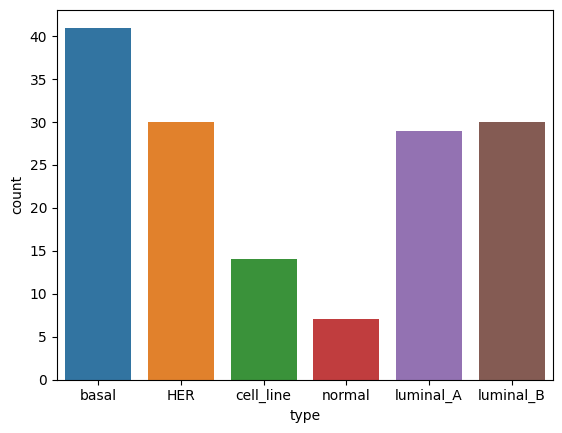

In [41]:
sns.countplot(data=data, x='type', hue='type')
plt.show()

In [42]:
data = data.drop(columns=['samples'])
data

,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,8.870780,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,7.767646,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,9.417956,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,9.022345,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,9.400056,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,luminal_B,10.392638,7.334408,6.848586,7.020486,3.228065,7.815439,5.448470,4.496955,8.015534,...,12.638556,12.122129,14.331152,14.133976,8.495888,4.971727,6.209136,2.852852,3.697448,3.333289
147,luminal_B,10.930875,8.415294,5.906827,7.753572,3.270557,7.367931,5.906849,5.194349,8.248133,...,12.523507,11.977970,14.285405,14.070989,8.193182,6.528948,7.108210,2.929800,3.833289,3.213893
148,luminal_B,11.027098,7.180876,6.304736,7.641197,3.206950,8.569296,5.823146,4.617309,7.523521,...,12.256767,11.661126,14.149586,13.977076,8.351331,6.882504,7.329545,3.085127,3.628848,3.215807
149,luminal_B,10.444395,7.525153,5.964460,7.825939,3.384147,7.268454,5.245072,5.088004,7.364773,...,12.321900,11.727694,14.186277,13.943521,7.927210,6.839086,7.089259,3.018525,3.770597,3.102298


In [43]:
data.isna().sum()

type               0
1007_s_at          0
1053_at            0
117_at             0
121_at             0
                  ..
AFFX-ThrX-5_at     0
AFFX-ThrX-M_at     0
AFFX-TrpnX-3_at    0
AFFX-TrpnX-5_at    0
AFFX-TrpnX-M_at    0
Length: 54676, dtype: int64

In [44]:
X = data.drop(columns=['type'])
y = data.type
X.shape, y.shape

((151, 54675), (151,))

# Scaler

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.79956253,  0.66184251,  0.31065541, ...,  0.51588188,
        -0.79712848,  1.26152126],
       [-0.78105222,  0.82416537,  1.30221516, ...,  0.17226811,
         0.43928775, -1.07876515],
       [-0.38504796,  1.85227675, -0.76001854, ..., -0.76591736,
        -0.50659316, -0.15095702],
       ...,
       [ 1.12558961, -0.64056402,  0.12412781, ...,  1.79227194,
         0.03339837,  0.41291911],
       [ 0.17254231, -0.15161854, -0.4048311 , ...,  1.07470717,
         1.01157301, -0.70464582],
       [ 1.64687488, -0.35876085, -0.51875725, ...,  1.53863231,
         1.61144015, -0.43360104]], shape=(151, 54675))

## Prueba primer LR

In [47]:
from sklearn.model_selection import train_test_split, cross_validate

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [49]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_model.score(X_test, y_test)

0.8387096774193549

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [51]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression())
])

param_grid = {
    "logistic__penalty": ["l1", "l2", "elasticnet"],
    "logistic__C": [0.001, 0.1, 1, 10]
    }

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)
grid_search.best_params_, grid_search.best_estimator_, grid_search.best_score_

c:\Users\ale_r\miniconda3\envs\entorno1\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ale_r\miniconda3\envs\entorno1\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

({'logistic__C': 0.1, 'logistic__penalty': 'l2'},
 Pipeline(steps=[('scaler', StandardScaler()),
                 ('logistic', LogisticRegression(C=0.1))]),
 np.float64(0.9416666666666667))

# PCA

In [52]:
from sklearn.decomposition import PCA

In [53]:
pca = PCA(0.95) # 95% de la varianza total
X_pca = pca.fit_transform(X)
X_pca.shape

(151, 115)

In [54]:
# Se redujo de 54675 a 115 filas entre el descarte y generación de nuevos componentes
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 115)


In [55]:
print(pca.explained_variance_ratio_) # Para observar el % que aporta cada componente

[0.16622808 0.09899693 0.06317803 0.03897045 0.03050308 0.02914394
 0.02350986 0.02049939 0.01896933 0.01513832 0.01232411 0.01153819
 0.01057066 0.00993929 0.00958428 0.00925465 0.00876365 0.00863102
 0.00805246 0.00786336 0.00781735 0.00774395 0.00723931 0.00718606
 0.00677813 0.0065674  0.00643165 0.00633043 0.00623969 0.00615798
 0.00603064 0.00580282 0.00561044 0.00554178 0.0054799  0.00535081
 0.0052455  0.0051477  0.00512369 0.00505192 0.00489115 0.00474917
 0.00469836 0.00464023 0.00456308 0.00450733 0.0043865  0.00427993
 0.00425096 0.00422941 0.00411197 0.00405822 0.00396185 0.00395281
 0.00388985 0.00384604 0.00377528 0.00374027 0.00371242 0.00358485
 0.00354708 0.00351431 0.00347818 0.00335696 0.0033419  0.00329846
 0.00324598 0.00318712 0.00317266 0.00314329 0.0031015  0.00307625
 0.00299573 0.00294905 0.00290362 0.00288007 0.00286348 0.00282437
 0.0027974  0.00275401 0.00273832 0.00272937 0.00266542 0.00262635
 0.00258228 0.00256625 0.00254906 0.00253979 0.00249299 0.0024

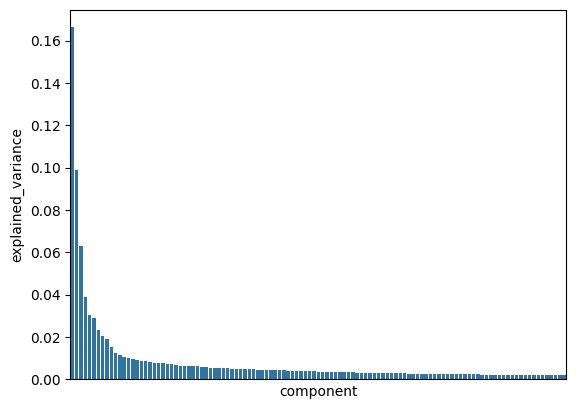

In [56]:
exp_variance = pd.DataFrame(pca.explained_variance_ratio_)
exp_variance["component"] = exp_variance.index + 1
exp_variance = exp_variance.rename(columns={0: "explained_variance"})

sns.barplot(exp_variance, x="component", y = "explained_variance")
plt.xticks([])
plt.show()

## Loadings

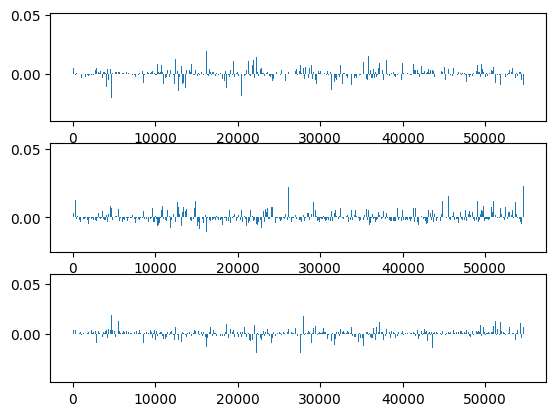

In [57]:
loadings = pd.DataFrame(pca.components_) # Loadings de cada componente

fig, axs = plt.subplots(3)
axs[0].bar(height = loadings.iloc[0], x = loadings.iloc[0].index) # Loadings del 1er componente
axs[1].bar(height = loadings.iloc[1], x = loadings.iloc[1].index) # Loadings del 2do componente
axs[2].bar(height = loadings.iloc[2], x = loadings.iloc[2].index) # Loadings del 3er componente
plt.show()

## Modelo tras el PCA

In [58]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)

In [59]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.9354838709677419

## PCA con menos componentes

In [60]:
pca = PCA(0.75)
X_pca = pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 46)


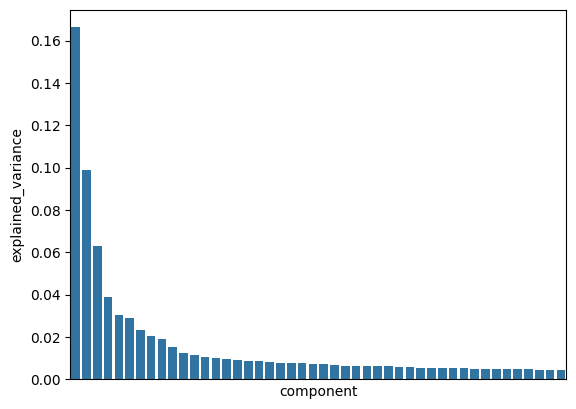

In [61]:
exp_variance = pd.DataFrame(pca.explained_variance_ratio_)
exp_variance["component"] = exp_variance.index + 1
exp_variance = exp_variance.rename(columns={0: "explained_variance"})

sns.barplot(exp_variance, x="component", y = "explained_variance")
plt.xticks([])
plt.show()

In [62]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.9354838709677419

### Prueba adicional: Menor porcentaje de varianza

- 85%

In [63]:
pca = PCA(0.85) # 85% de la varianza total
X_pca = pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 73)


In [64]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.9032258064516129

- 75%

In [65]:
pca = PCA(0.75) # 75% de la varianza total
X_pca = pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 46)


In [66]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.9354838709677419

- 65%

In [67]:
pca = PCA(0.65) # 65% de la varianza total
X_pca = pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 27)


In [68]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.8709677419354839

- 45%

In [69]:
pca = PCA(0.45) # 45% de la varianza total
X_pca = pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 7)


In [70]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.967741935483871

- 25%

In [71]:
pca = PCA(0.25) # 25% de la varianza total
X_pca = pca.fit_transform(X)
print(X.shape)
print(X_pca.shape)

(151, 54675)
(151, 2)


In [72]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=1)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_pca)
model.score(X_test_pca, y_test_pca)

0.9032258064516129

Observaciones: se obtiene un mejor score con 45% que al usar un 75% o 95% de varianza, por lo cual es mejor el uso del 45, mas curiosamente no es directamente lineal la mejora, pues con 65% se obtiene un peor score que 75%.

Esto podría indicar que la cantidad grande de componentes podría afectar con overfitting al modelo, planteando que menos componentes son necesarios para realizar una mejor predicción, incluso obteniendo un mejor score que en el caso de la LR usual o incluso el Grid Search.